## MNIST digit classification using ConvNets

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size = 2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28,28,1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28,28,1))
test_images = test_images.astype("float32") / 255

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9506 - loss: 0.1602
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.9870 - loss: 0.0434
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.9909 - loss: 0.0296
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9931 - loss: 0.0222
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9949 - loss: 0.0166


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9932 - loss: 0.0235
Test accuracy: 0.993


### training on cats vs dogs dataset

## Cats vs Dogs Dataset Classification

This section focuses on building and training a convolutional neural network (CNN) to classify images of cats and dogs. We will explore different techniques including data preprocessing, data augmentation, feature extraction using a pre-trained model (VGG16), and fine-tuning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/archive.zip" -d "/content/dataset"


### sampling the data to contain 2000 train images, 1000 validation images & 2000 test images

In [ ]:
import os, shutil, pathlib
from PIL import Image

# 1. Update these paths to match your unzipped dataset layout
# (Assuming your unzipped folder contains a 'PetImages' directory)
original_dir = pathlib.Path("/content/dataset/PetImages")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

def is_valid_image(filepath):
    """Checks if an image file is valid and can be opened by PIL, and has a supported channel count."""
    try:
        with Image.open(filepath) as img:
            img.verify()  # Verify integrity
            # Check for supported number of channels (1 for grayscale, 3 for RGB, 4 for RGBA)
            # TensorFlow decode_image typically expects 1, 3, or 4 channels.
            if img.mode not in ['L', 'RGB', 'RGBA']:
                print(f"Warning: Skipping unsupported image mode {img.mode} for {filepath}")
                return False
        return True
    except (IOError, SyntaxError) as e:
        print(f"Warning: Skipping corrupted image {filepath}: {e}")
        return False

def make_subset(subset_name, start_index, end_index):
    for category in ("Cat", "Dog"): # Note the capital letters to match your folder
        # Create destination folder (lowercase 'cat'/'dog' to match your book)
        dst_dir = new_base_dir / subset_name / category.lower()
        os.makedirs(dst_dir, exist_ok=True)

        # Loop through the specified range of image indices
        for i in range(start_index, end_index):
            fname = f"{i}.jpg"
            src = original_dir / category / fname
            dst = dst_dir / f"{category.lower()}.{i}.jpg" # Renames to book style

            # Skip corrupted/missing images if any exist in the downloaded set
            if src.exists() and is_valid_image(src): # Validate image before copying
                shutil.copyfile(src=src, dst=dst)
            elif not src.exists():
                print(f"Warning: Skipping missing image {src}")

# 2. Run the subsets exactly like your book requires
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

The `make_subset` function is used to create training, validation, and test sets from the original dataset. It copies a specified range of images for each category ('Cat' and 'Dog') into new, organized directories. A crucial step here is to validate each image before copying. If an image is found to be corrupted or has an unsupported format (e.g., 2 channels), it is skipped. This helps prevent `InvalidArgumentError` during later data loading with `image_dataset_from_directory`.

In [ ]:
### instantiating a small convnet for dogs vs cats dataset

inputs = keras.Input(shape=(180,180,3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters= 256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

### Instantiating a Small ConvNet for Dogs vs Cats

We define a small convolutional neural network from scratch for the binary classification task. The network architecture consists of several `Conv2D` and `MaxPooling2D` layers, followed by a `Flatten` layer and a `Dense` output layer with a sigmoid activation for binary classification.

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

### Compiling the Model

After defining the model architecture, we compile it with appropriate loss function, optimizer, and metrics.

*   **Loss Function**: `binary_crossentropy` is used for binary classification problems.
*   **Optimizer**: `rmsprop` is a good choice for many CNNs.
*   **Metrics**: `accuracy` is used to monitor the model's performance during training.

#### Data preprocessing using image_dataset_from_directory()

Since corrupted images were removed, we need to regenerate the datasets to reflect these changes. Rerunning the `image_dataset_from_directory` calls will ensure the datasets only contain valid image files.

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

# Re-create the datasets from the cleaned directories
train_dataset= image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180,180),
    batch_size=32
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180,180),
    batch_size=32
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180,180),
    batch_size=32
)

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
##dispalying the shape of the data and labels yielded by the dataset

for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


### Training and Evaluating the Small ConvNet

The model is trained using the `train_dataset` and validated on `validation_dataset`. A `ModelCheckpoint` callback is used to save the model weights that achieve the best validation loss.

After training, the model's performance is evaluated on the `test_dataset` to get an unbiased estimate of its generalization capability.

In [ ]:
callbacks= [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks
    )

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.5153 - loss: 0.7016 - val_accuracy: 0.5630 - val_loss: 0.6907
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.5218 - loss: 0.6932 - val_accuracy: 0.5030 - val_loss: 0.6935
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.5728 - loss: 0.6828 - val_accuracy: 0.4990 - val_loss: 0.8054
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.6238 - loss: 0.6655 - val_accuracy: 0.5670 - val_loss: 0.7198
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.6353 - loss: 0.6451 - val_accuracy: 0.5720 - val_loss: 0.8805
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6733 - loss: 0.6117 - val_accuracy: 0.6850 - val_loss: 0.5904
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.6938 - loss: 0.5933 - val_accuracy: 0.6700 - val_loss: 0.6233
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.7064 - loss: 0.5632 - val_accuracy: 0.6800 - v

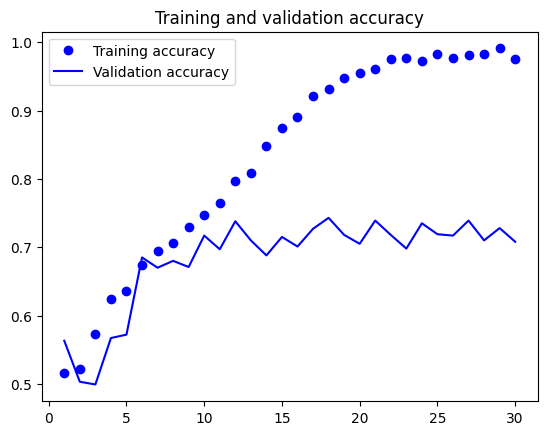

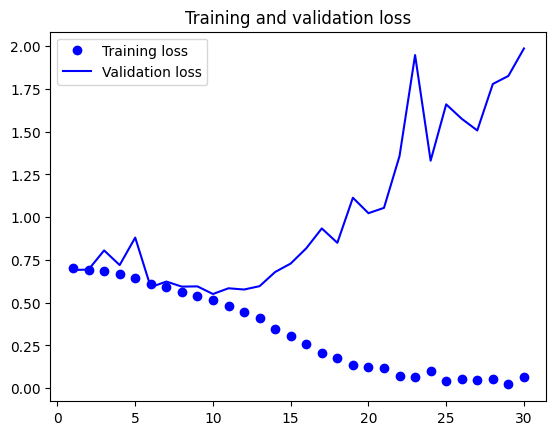

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

 6/63 ━━━━━━━━━━━━━━━━━━━━ 41s 727ms/step - accuracy: 0.6901 - loss: 0.5444

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Number of channels inherent in the image must be 1, 3 or 4, was 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_15339]

##### Using data augmentation

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

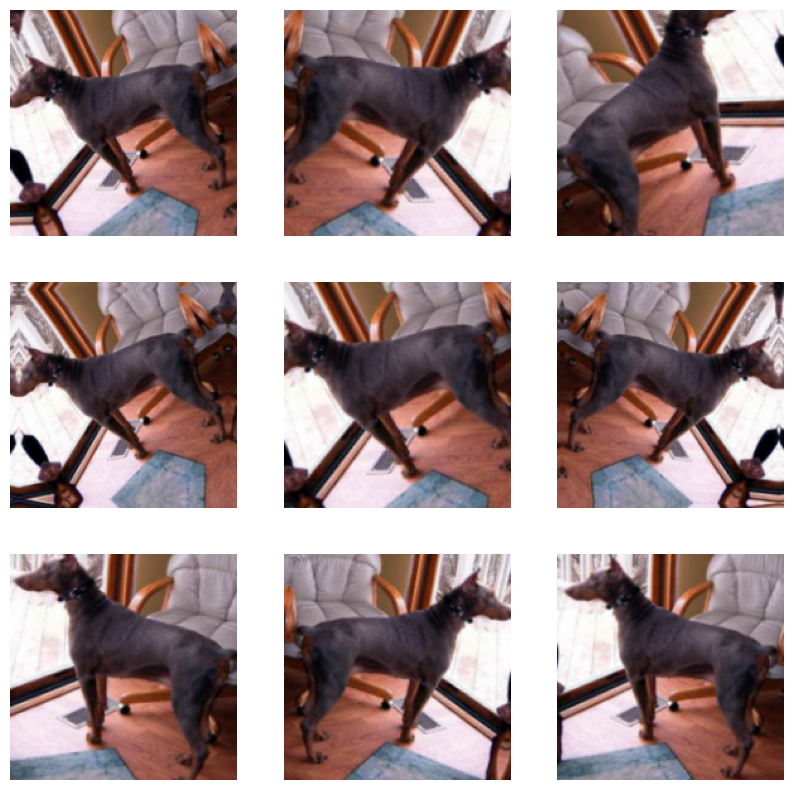

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3,3,i+1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

#### Defining a new convnet that includes image augmentation and dropout

### Defining a New ConvNet with Image Augmentation and Dropout

To combat overfitting, especially with smaller datasets, we introduce two key techniques:

1.  **Data Augmentation**: A `keras.Sequential` layer (`data_augmentation`) applies random transformations (flipping, rotation, zooming) to the input images during training. This artificially expands the training dataset, helping the model generalize better.
2.  **Dropout**: A `layers.Dropout(0.5)` layer is added before the final `Dense` layer. Dropout randomly sets a fraction of input units to 0 at each update during training, which prevents co-adaptation of neurons and reduces overfitting.

In [ ]:
inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x =layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/Colab Notebooks/convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )]
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.5263 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - accuracy: 0.5143 - loss: 0.6946 - val_accuracy: 0.6010 - val_loss: 0.6907
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 233s 4s/step - accuracy: 0.5418 - loss: 0.6931 - val_accuracy: 0.5600 - val_loss: 0.6849
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.5583 - loss: 0.6908 - val_accuracy: 0.5570 - val_loss: 0.6767
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.6203 - loss: 0.6578 - val_accuracy: 0.6350 - val_loss: 0.6291
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.6363 - loss: 0.6444 - val_accuracy: 0.6670 - val_loss: 0.6130
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.6558 - loss: 0.6284 - val_accuracy: 0.5960 - val_loss: 0.6407
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.6668 - loss: 0.6148 - val_accuracy: 0.

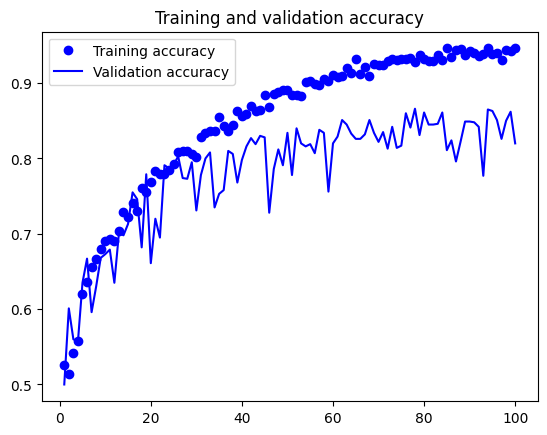

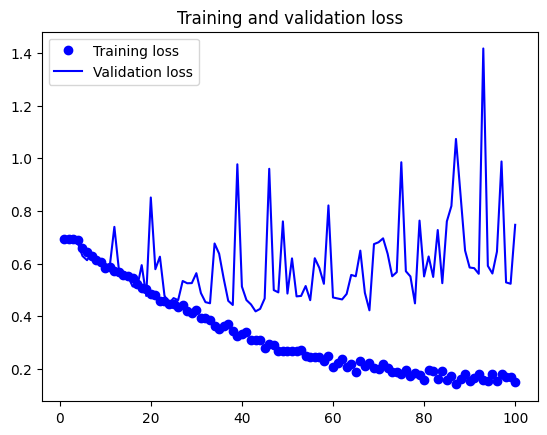

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Training and Evaluating the Model with Data Augmentation

This section trains the previously defined convolutional network which now includes data augmentation and dropout layers. The training process is similar, but with potentially more epochs to allow the model to learn from the augmented data. The `ModelCheckpoint` callback continues to save the best performing model based on validation loss.

In [ ]:
test_model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

 5/63 ━━━━━━━━━━━━━━━━━━━━ 1:03 1s/step - accuracy: 0.7803 - loss: 0.5669

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Input size should match (header_size + row_size * abs_height) but they differ by 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_47274]

### Using Pretrained Models

## Using Pretrained Models for Feature Extraction

Instead of training a convolutional base from scratch, we can leverage pre-trained models, such as VGG16, which have learned powerful features from vast datasets like ImageNet. This approach is called **feature extraction**.

Here, we instantiate the `VGG16` convolutional base, excluding its top (classification) layers, and set `include_top=False`. The `weights='imagenet'` argument loads the pre-trained weights.

In [ ]:
#Instanting VGG16 convolution base

conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180,180,3)
)

conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

def get_features_and_labels(dataset):
  all_features = []
  all_labels = []
  for images, labels in dataset:
    preprocessed_images = keras.applications.vgg16.preprocess_input(images)
    features = conv_base.predict(preprocessed_images)
    all_features.append(features)
    all_labels.append(labels)
  return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2
	 [[{{node decode_image/DecodeImage}}]] [Op:IteratorGetNext] name: 

### Extracting Features and Labels

The `get_features_and_labels` function processes a given dataset through the pre-trained `conv_base`. For each batch of images, it first preprocesses them using `keras.applications.vgg16.preprocess_input` (which performs tasks like mean subtraction and pixel scaling specific to VGG16), then uses the `conv_base.predict` method to extract features. These features and their corresponding labels are collected and concatenated to form numpy arrays, which will then be used to train a new, smaller classifier.

In [ ]:
#defining and training a densely connected classifier
inputs = keras.Input(shape=(5,5,512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )]
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)

### Defining and Training a Densely Connected Classifier

After extracting features from the `conv_base`, we build a new, simpler model (a densely connected classifier) on top of these features. Since the `conv_base` is pre-trained, we only need to train this smaller classifier. The architecture typically involves a `Flatten` layer to convert the 3D feature maps into 1D vectors, followed by `Dense` layers and a `Dropout` layer to prevent overfitting.

The model is compiled with `binary_crossentropy` and `rmsprop`, and trained using the extracted `train_features` and `train_labels`, validated on `val_features` and `val_labels`.

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Training and Evaluation of the Densely Connected Classifier

This section trains the densely connected classifier on the features extracted from the pre-trained VGG16. The training history is then plotted to visualize the accuracy and loss curves for both training and validation datasets. This helps in understanding the model's learning progress and identifying potential overfitting.

In [ ]:
##instantiating and freezing VGG16 convolutional base
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,)
conv_base.trainable = False

conv_base.summary()

### Fine-tuning the Pretrained Model

Fine-tuning is an advanced technique where, after feature extraction, we unfreeze a few of the top layers of the convolutional base and train the entire model (the unfrozen layers of the `conv_base` plus the newly added classifier) with a very low learning rate. This allows the model to adapt the pre-trained features to the specific dataset, potentially achieving better performance.

Here, we freeze the entire `conv_base` initially, then carefully unfreeze only the top convolutional blocks (e.g., the last four layers) to allow them to be trained.

In [ ]:
#addding data augmentation stage and a classifier  to the convolutional base

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        ])

inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/Colab Notebooks/feature_extraction_with_data_augmentation_and_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss"
    )]

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

### Building and Training the Model with Fine-tuning

This section defines the full model for fine-tuning. It incorporates the `data_augmentation` layer, the pre-trained `conv_base` (with some layers unfrozen), and the custom `Dense` classifier. The model is compiled with a very low learning rate for the `rmsprop` optimizer, which is crucial for fine-tuning to prevent large updates to the pre-trained weights. The model is then trained on the `train_dataset` with validation on `validation_dataset`.

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Training History for Fine-tuned Model

These plots display the training and validation accuracy and loss for the model after fine-tuning. Comparing these plots with previous training runs helps assess the impact of fine-tuning on the model's performance and generalization.

In [ ]:
test_model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/feature_extraction_with_data_augmentation_and_fine_tuning.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")


In [ ]:
##unfreezing the top layers of convolutional base
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
  layer.trainable = False

  model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
                metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/Colab Notebooks/fine_tuning.keras",
        save_best_only= True,
        monitor="val_loss")]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

### Unfreezing Layers for Fine-tuning

Before training the full model, we selectively unfreeze a portion of the `conv_base`. The typical strategy is to keep the early layers (which learn more generic features) frozen and unfreeze the later layers (which learn more specific features relevant to the target dataset). Here, we unfreeze the entire `conv_base` and then explicitly set the `trainable` attribute of all layers except the last four to `False`. This allows only the deeper, more specialized layers of VGG16 to be fine-tuned along with the custom classifier.

Following this, the model is re-compiled with a very low learning rate, ensuring that the gradient updates during fine-tuning are small and do not drastically alter the pre-trained weights.

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Final Training History for Fine-tuning

These plots show the training and validation accuracy and loss during the final fine-tuning phase. A stable validation loss and increasing accuracy indicate successful fine-tuning. It's important to monitor these plots to prevent overfitting during this stage, as the model has more trainable parameters.

## Conclusion

This notebook demonstrates several techniques for image classification, starting with a basic Convolutional Neural Network (CNN) on the MNIST dataset, and then progressing to more complex strategies for the 'Cats vs Dogs' dataset. Key concepts covered include:

*   **CNN Fundamentals**: Building and training a simple CNN.
*   **Data Preprocessing**: Handling image files and creating balanced datasets.
*   **Data Augmentation**: Employing techniques like random flips, rotations, and zooms to enhance model generalization and combat overfitting, especially with limited data.
*   **Feature Extraction with Pre-trained Models**: Utilizing a pre-trained VGG16 model as a feature extractor, leveraging its learned hierarchical features.
*   **Fine-tuning**: Adapting a pre-trained model to a specific task by unfreezing and retraining a subset of its layers with a very low learning rate.

Each step highlights the challenges and solutions in image classification, culminating in strategies that improve model performance and robustness against overfitting. The visualizations of training and validation metrics provide insights into the learning process and help evaluate the effectiveness of different approaches.